# Robusta Experiments
Trying out robusta-hmf on hot star subsamples

## Revision history
- last updated by Nana 2026-06-30

## Notes and bugs and to-dos:
-  Notes: This works off by the data by the notebook called make_hot_star_samples, see notebook for file contents


In [23]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from robusta_hmf import Robusta
import time

In [2]:
start = time.perf_counter()

In [4]:
#define constants
c = 299792.458 #km/s
LN10 = np.log(10.)
MAX_IVAR = 2.5e3
MIN_IVAR = 0.1

In [5]:
#read in the data and deal with radial velocities
with open('hot_stars_20000_2026-06-30_data.pkl','rb') as f:
     fluxes, loglam, ivars, continuua, spec_files, rvs = pickle.load(f)
print(fluxes.shape, loglam.shape, ivars.shape, continuua.shape, spec_files.shape)

(20000, 4648) (4648,) (20000, 4648) (20000, 4648) (20000,)


In [6]:
#log lambda values have been corrupted
print(10**loglam)
print(loglam[1:] - loglam[:-1])
print(np.median(loglam[1:] - loglam[:-1]))
delta_log_lambda_pixel = np.median(loglam[1:] - loglam[:-1])

[ 3566.9744  3567.795   3568.6177 ... 10394.412  10396.809  10399.206 ]
[9.9897385e-05 1.0013580e-04 9.9897385e-05 ... 1.0013580e-04 1.0013580e-04
 1.0013580e-04]
9.9897385e-05


In [7]:
#get ready to do pixel shifts
delta_log_lambdas = (rvs / c) / LN10
delta_pixels = np.round(delta_log_lambdas/delta_log_lambda_pixel).astype(int)

print(delta_log_lambdas, delta_pixels)

[ 2.72608685e-05 -1.04017227e-04 -8.58678348e-05 ... -1.93969021e-05
 -4.43710546e-06 -8.83137226e-05] [ 0 -1 -1 ...  0  0 -1]


In [8]:
#shift spectra to the rest frame
## johanna is not going to like this

rest_fluxes = np.zeros_like(fluxes) + 1.
rest_ivars = np.zeros_like(ivars)
rest_continuua = np.zeros_like(continuua) + np.nan
for i, dp in enumerate(delta_pixels):
    if dp < 0:
        rest_fluxes[i, -dp:] = fluxes[i, :dp]
        rest_ivars[i, -dp:] = ivars[i, :dp]
        rest_continuua[i, -dp:] = continuua[i, :dp]
        
    elif dp > 0:
        rest_fluxes[i, :-dp] = fluxes[i, dp:]
        rest_ivars[i, :-dp] = ivars[i, dp:]
        rest_continuua[i, :-dp] = continuua[i, dp:]
        
    else:
        rest_fluxes[i, :] = fluxes[i, :]
        rest_ivars[i, :] = ivars[i, :]
        rest_continuua[i, :] = continuua[i, :]


-5
2805


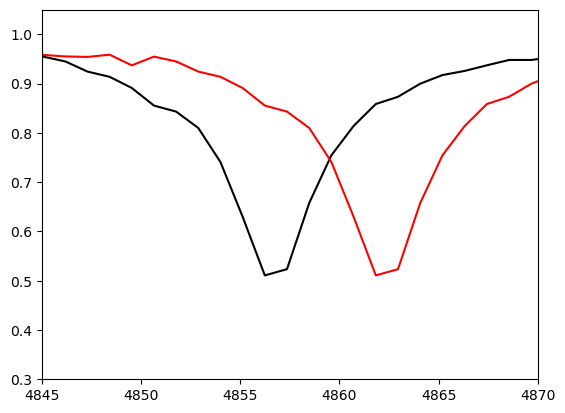

In [9]:
# spot check the above
print(np.min(delta_pixels))
largest_shift = np.argmin(delta_pixels)
print(largest_shift)

plt.plot(10**loglam, fluxes[largest_shift], 'k-')
plt.plot(10**loglam, rest_fluxes[largest_shift], 'r-')
plt.xlim(4845, 4870)
plt.axvline(4471.48)
plt.ylim(0.3,1.05)
plt.show()


In [10]:
#fix nans and infinities
bad = np.logical_not(np.isfinite(rest_fluxes))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = np.logical_not(np.isfinite(rest_ivars))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = np.logical_or((rest_fluxes > 2.0), (rest_fluxes < 0))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = rest_ivars > MAX_IVAR
# rest_fluxes[bad] = 1
# rest_ivars[bad] = 0
rest_ivars[bad] = MAX_IVAR

bad = ivars < MIN_IVAR
rest_fluxes[bad] = 1.0
rest_ivars[bad] = MIN_IVAR

In [11]:
print(f"flux median: {np.median(rest_fluxes)}, ivar median{np.median(rest_ivars)}")
print(np.max(rest_fluxes), np.min(rest_fluxes))
print(np.max(rest_ivars), np.min(rest_ivars))

flux median: 0.9972217650001955, ivar median856.6674498100901
1.9999801991699797 8.909031804004186e-07
2500.0 0.0


In [12]:
# split data into an A sample and a B sample
N, M = fluxes.shape
foo = np.arange(N)
rng = np.random.default_rng(17)
rng.shuffle(foo)
Aindx = foo[:N // 2]
Bindx = foo[N // 2:]


In [13]:
#we are using the rest frame data as our data 
data = rest_fluxes
weights = rest_ivars

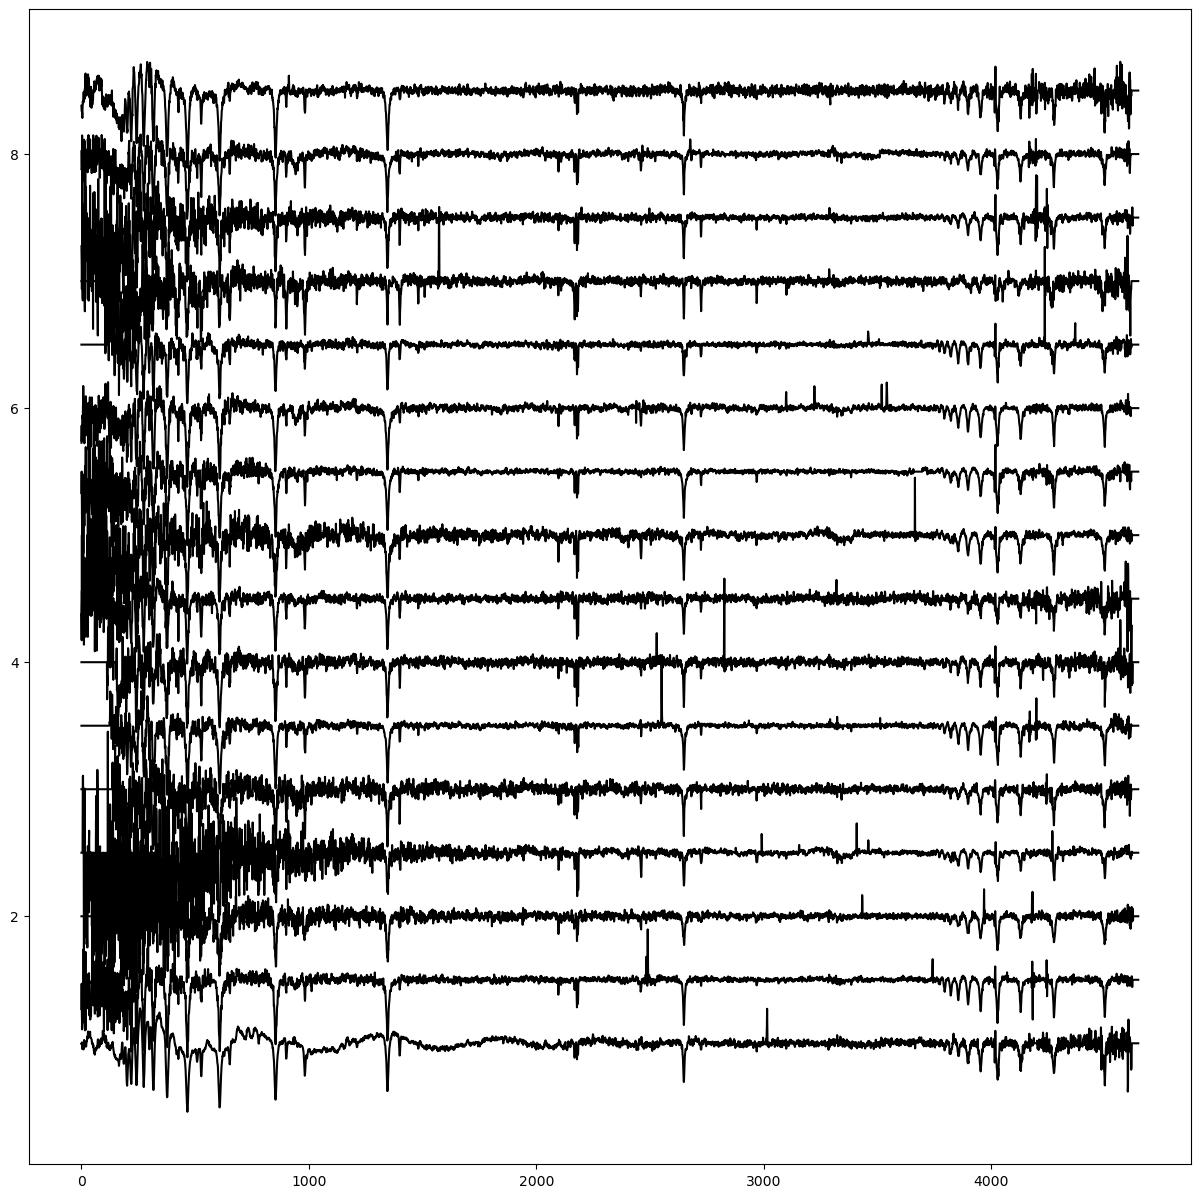

In [14]:
# plot some of the data from sample B just to look
f = plt.figure(figsize=(15, 15))
offset = 0.5
for i in range(16):
    f.gca().plot(data[Bindx[i]] + i * offset, color="k")

In [15]:
# train two Robusta models
K = 16
#foo, bar = 2500, 4500
modelA = Robusta(rank=K, robust=True)
modelB = Robusta(rank=K, robust=True)
fooA = modelA.fit(data[Aindx], weights[Aindx], max_iter = 10000)
#fooA = modelA.fit(data[Aindx, foo:bar], weights[Aindx, foo:bar], max_iter = 10000)
#fooB = modelB.fit(data[Bindx, foo:bar], weights[Bindx, foo:bar], max_iter = 10000)


Initializing state... done.
iter 011 | loss 11787176.0923
iter 021 | loss 11754494.0077
iter 031 | loss 11747726.3885
iter 041 | loss 11745783.2916
iter 051 | loss 11745069.3395
iter 061 | loss 11744800.0983
iter 071 | loss 11744664.1902
iter 081 | loss 11744581.0171
iter 091 | loss 11744538.8989
iter 101 | loss 11744514.4563
iter 111 | loss 11744499.2588
iter 121 | loss 11744488.8470
iter 131 | loss 11744480.4139
iter 141 | loss 11744473.2695
iter 151 | loss 11744468.6063
iter 161 | loss 11744465.1576
iter 171 | loss 11744462.4401
iter 181 | loss 11744460.2812
iter 191 | loss 11744458.5060
iter 201 | loss 11744456.9947
iter 211 | loss 11744455.6640
iter 221 | loss 11744454.4583
iter 231 | loss 11744453.3455
iter 241 | loss 11744451.8067
iter 251 | loss 11744450.8220
iter 261 | loss 11744450.1200
iter 271 | loss 11744449.5072
iter 281 | loss 11744448.9734
iter 291 | loss 11744448.5100
iter 301 | loss 11744448.1038
iter 311 | loss 11744447.7435
iter 321 | loss 11744447.4168
iter 331 | l

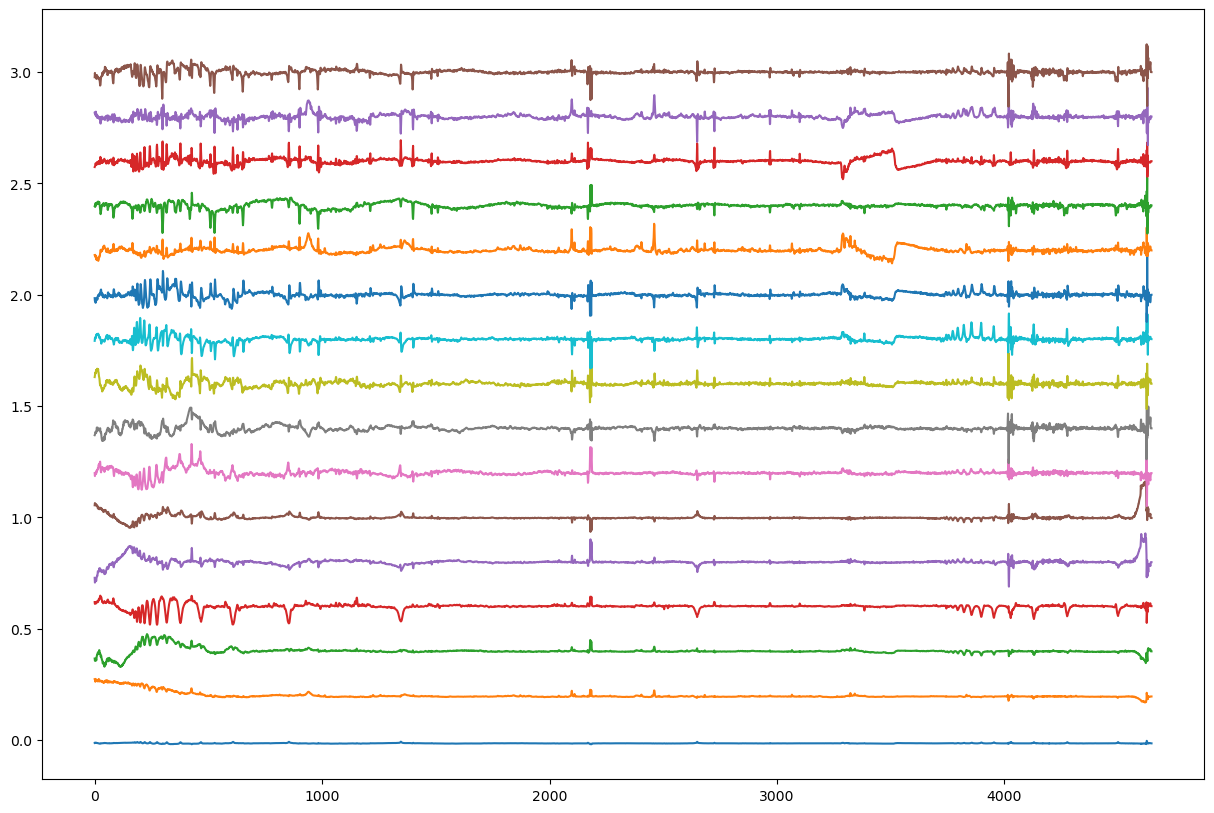

In [21]:
# plot the eigenspectra
eigsA = modelA.basis_vectors().T
# eigsB = modelB.basis_vectors().T
f = plt.figure(figsize=(15, 10))
offset = 0.2
for i in range(K):
    f.gca().plot(eigsA[i] + i * offset)
    # f.gca().plot(eigsB[i] + i * offset, alpha=0.5)

In [17]:
# infer at the other (complementary, or held-out) samples

#state, _ = modelA.infer(data[Bindx, foo:bar], weights[Bindx, foo:bar])
state, _ = modelA.infer(data[Bindx], weights[Bindx])


print(state)
synth = modelA.synthesize(state)
print(synth.shape)

iter 011 | loss 11854097.4331
iter 021 | loss 11853702.4062
iter 031 | loss 11853621.0885
Converged at iteration 40
RHMFState(A=f64[10000,16], G=f64[4648,16], it=weak_i64[])
(10000, 4648)


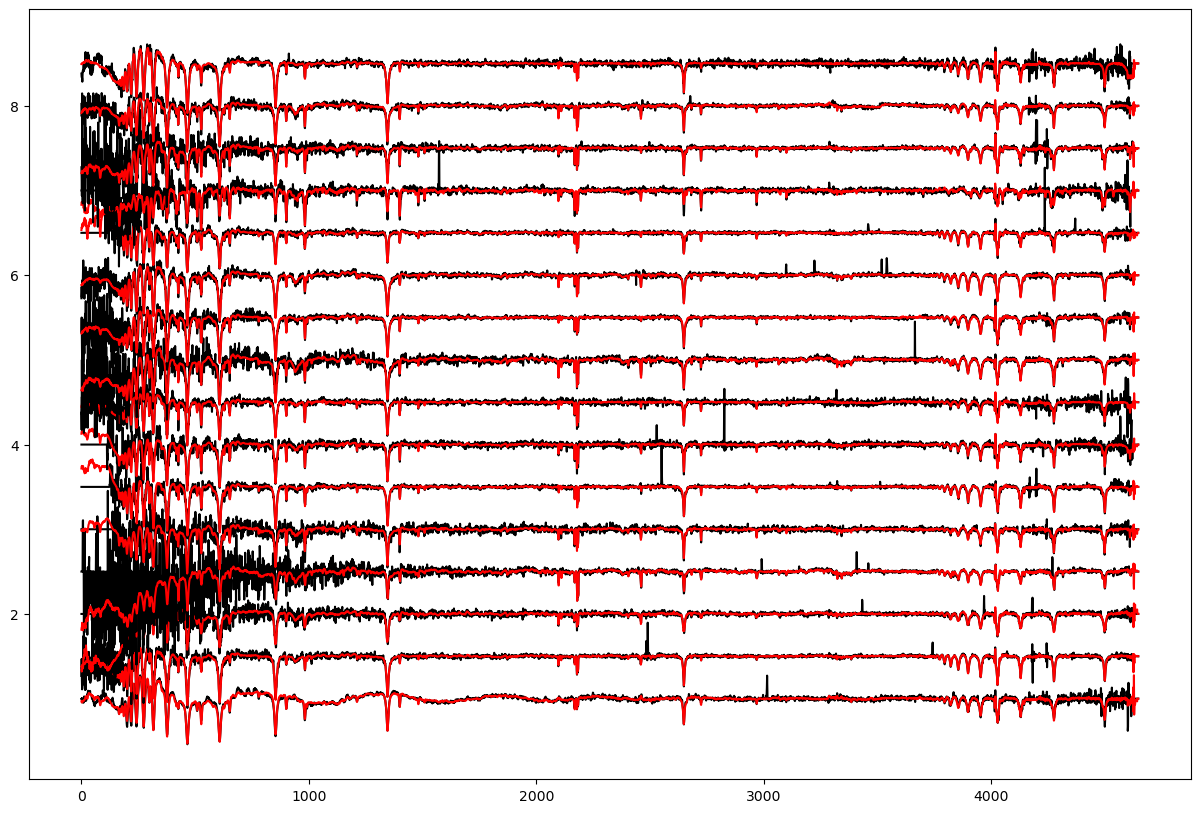

In [22]:
# plot examples
f = plt.figure(figsize=(15, 10))
offset = 0.5
for i in range(16):
    f.gca().plot(data[Bindx[i]] + i * offset, color="k")
    f.gca().plot(synth[i] + i * offset, color="r")
#plt.savefig('example_robosuta_hmf.png', dpi=300, bbox_inches='tight')

In [19]:
#make pickle for hogg

# file_prefix = "data_weights_subsample_2026-06-29"
# with open(file_prefix + ".pkl", "wb") as file:
#     pickle.dump((data[Aindx], weights[Aindx]), file)

In [20]:
end = time.perf_counter()
print("total time:", (end - start)/60, "minutes")

total time: 7.01899920625001 minutes
